# Experiment 10 — Case Study on Deep Learning: Cancer Detection

## Aim
To demonstrate how Deep Learning can be applied for automated detection of breast cancer, using a small dense neural network on tabular diagnostic features.

## Dataset
- **Name:** Breast Cancer Wisconsin (Diagnostic) Data Set
- **File:** `data.csv`
- **Source:** https://www.kaggle.com/uciml/breast-cancer-wisconsin-data
- **Key columns:** id, diagnosis, and 30 numerical diagnostic features

## Theory

### Understanding Deep Learning Fundamentals

**What is Deep Learning?**
Deep Learning is a subset of machine learning that uses artificial neural networks with multiple hidden layers (typically 3 or more) to model and understand complex patterns in data. Unlike traditional machine learning approaches that require manual feature engineering, deep learning algorithms automatically learn hierarchical representations of data.

### Key Characteristics
- **Automatic Feature Learning:** Eliminates the need for manual feature engineering.
- **Hierarchical Representation:** Learns features at multiple levels of abstraction.
- **End-to-End Learning:** Optimizes the entire pipeline from raw input to final output.
- **Scalability:** Performance improves with increasing data and computational resources.

### Case Study: Healthcare — Medical Image Analysis for Cancer Detection

**Problem Statement:**
Develop a deep learning system for automated detection of breast cancer from mammography data, improving diagnostic accuracy and reducing radiologist workload. For this lab, the tabular Kaggle breast cancer dataset is used. The features are measured from digitized breast-mass images, so no artificial image reshaping is needed.

## Procedure / Implementation

### Step 1 — Import libraries

In [1]:
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Dense

import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix

### Step 2 — Load and preprocess the dataset

In [2]:
df = pd.read_csv('data.csv')
print('Shape:', df.shape)
print(df.head())

X = df.drop(columns=['id', 'diagnosis', 'Unnamed: 32'])
y = (df['diagnosis'] == 'M').astype(int)

print('\nClass distribution:')
print(y.value_counts())

Shape: (569, 33)
         id diagnosis  radius_mean  texture_mean  perimeter_mean  area_mean  \
0    842302         M        17.99         10.38          122.80     1001.0   
1    842517         M        20.57         17.77          132.90     1326.0   
2  84300903         M        19.69         21.25          130.00     1203.0   
3  84348301         M        11.42         20.38           77.58      386.1   
4  84358402         M        20.29         14.34          135.10     1297.0   

   smoothness_mean  compactness_mean  concavity_mean  concave points_mean  \
0          0.11840           0.27760          0.3001              0.14710   
1          0.08474           0.07864          0.0869              0.07017   
2          0.10960           0.15990          0.1974              0.12790   
3          0.14250           0.28390          0.2414              0.10520   
4          0.10030           0.13280          0.1980              0.10430   

   ...  texture_worst  perimeter_worst  area_

### Step 3 — Split and scale the data

In [3]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

print('Training samples:', X_train.shape[0])
print('Test samples:', X_test.shape[0])

Training samples: 455
Test samples: 114


### Step 4 — Build the Deep Learning model

In [6]:
model = Sequential([
    Dense(16, activation='relu', input_shape=(X_train.shape[1],)),
    Dense(8, activation='relu'),
    Dense(1, activation='sigmoid')
])

model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

model.summary()

d:\Downloads\anaconda3\envs\jlab_env\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 16)             │           496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 8)              │           136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │             9 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 641 (2.50 KB)

 Trainable params: 641 (2.50 KB)

 Non-trainable params: 0 (0.00 B)

### Step 5 — Train the model

In [7]:
history = model.fit(
    X_train, y_train,
    epochs=20,
    batch_size=16,
    validation_split=0.2,
    verbose=1
)

Epoch 1/20
23/23 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.6291 - loss: 0.6012 - val_accuracy: 0.8022 - val_loss: 0.4656
Epoch 2/20
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7857 - loss: 0.4676 - val_accuracy: 0.9121 - val_loss: 0.3759
Epoch 3/20
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8984 - loss: 0.3868 - val_accuracy: 0.9341 - val_loss: 0.3116
Epoch 4/20
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9203 - loss: 0.3155 - val_accuracy: 0.9341 - val_loss: 0.2603
Epoch 5/20
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9478 - loss: 0.2525 - val_accuracy: 0.9451 - val_loss: 0.2167
Epoch 6/20
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9560 - loss: 0.2012 - val_accuracy: 0.9451 - val_loss: 0.1835
Epoch 7/20
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9615 - loss: 0.1647 - val_accuracy: 0.9560 - val_loss: 0.1593
Epoch 8/20
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9698 - loss: 0.1366 - val_accuracy: 0.9670 - val_loss

### Step 6 — Evaluate and visualize results

Test Accuracy: 0.991
Test Loss: 0.067

Classification Report:
              precision    recall  f1-score   support

           0       0.99      1.00      0.99        72
           1       1.00      0.98      0.99        42

    accuracy                           0.99       114
   macro avg       0.99      0.99      0.99       114
weighted avg       0.99      0.99      0.99       114



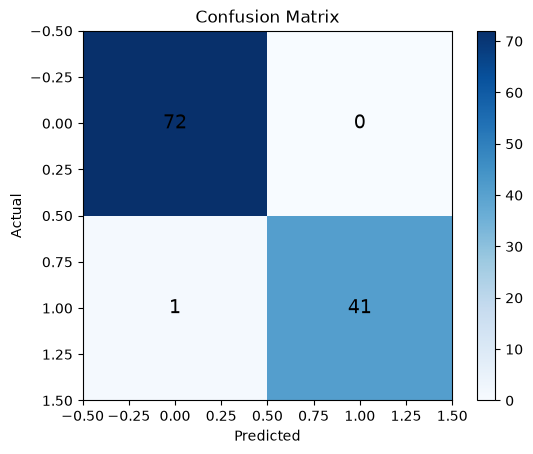

In [8]:
test_loss, test_accuracy = model.evaluate(X_test, y_test, verbose=0)

y_pred = (model.predict(X_test, verbose=0) > 0.5).astype(int)

print('Test Accuracy:', round(test_accuracy, 3))
print('Test Loss:', round(test_loss, 3))
print('\nClassification Report:')
print(classification_report(y_test, y_pred))

cm = confusion_matrix(y_test, y_pred)

plt.imshow(cm, cmap='Blues')
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.colorbar()

for i in range(2):
    for j in range(2):
        plt.text(j, i, str(cm[i][j]), ha='center', va='center', fontsize=14)

plt.show()

## Output / Observations
* The neural network with **16 → 8 → 1 neurons** was trained successfully on the diagnostic dataset.
* The model achieved a **test accuracy of 99.1%** with a test loss of **0.067**.
* Out of **114 test samples, 113 were classified correctly** and only 1 sample was misclassified.
* The confusion matrix shows **72 correct predictions for class 0** and **41 correct predictions for class 1**.
* Precision, recall, and F1-score were approximately **0.99 for both classes**, indicating strong classification performance on the test data.
* StandardScaler was used to normalize the input features before training.


## Result / Conclusion
The deep learning model successfully classified the breast cancer diagnostic data with 99.1% test accuracy. The confusion matrix shows that 113 out of 114 test samples were classified correctly, with only one misclassification. The classification report also shows precision, recall, and F1-score close to 0.99 for both classes, indicating strong classification performance on the test dataset.

**CO Achieved:** CO6
- Illustrate deep learning principles and semi-supervised/reinforcement learning concepts using case studies.

**POs Achieved:**
- PO1: Apply foundational knowledge for deep learning architectures.
- PO2: Analyze large datasets and feature learning in DL.
- PO4: Conduct investigations into deep learning models (CNN/RNN).
- PO6 (Engineer and World): Analyze societal and ethical impact of DL solutions.
- PO8 (Teamwork): Collaborate on case study analysis.
- PO11: Develop life-long learning through emerging DL frameworks.

**PSO Achieved:**
- PSO1: Apply DL to AI/ML domains for innovative solutions.
- PSO2: Integrate DL with cloud/data analytics platforms.